# Burger's Equation

$$u_t + uu_x = \nu u_{xx}$$

- **$u(x,t)$**: Solution in velocity field  
- **$\nu$**: viscosity  
- **$x$**: $\in [-1,1]$  
- **$t$**: $\in [0,1]$

In [5]:
import sys
print(sys.executable)

/usr/local/bin/python


In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
print(device)

cpu


In [14]:
nu = 0.01/np.pi

In [15]:
# Neural Network
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = PINN().to(device)

In [ ]:
# Training data
N_f = 10000   
N_bc = 200
N_ic = 200

In [ ]:
# Collocation points 
x_f = torch.rand(N_f,1)*2 - 1
t_f = torch.rand(N_f,1)

# Initial condition
x_ic = torch.rand(N_ic,1)*2 - 1
t_ic = torch.zeros_like(x_ic)
u_ic = -torch.sin(np.pi * x_ic)

# Boundary condition
t_bc = torch.rand(N_bc,1)
x_bc_left = -torch.ones_like(t_bc)
x_bc_right = torch.ones_like(t_bc)



In [ ]:
# Move to device
x_f, t_f = x_f.to(device), t_f.to(device)
x_ic, t_ic, u_ic = x_ic.to(device), t_ic.to(device), u_ic.to(device)
x_bc_left, x_bc_right, t_bc = x_bc_left.to(device), x_bc_right.to(device), t_bc.to(device)

In [17]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Training loop
for epoch in range(5000):
    optimizer.zero_grad()

    x_f.requires_grad = True
    t_f.requires_grad = True

    u = model(x_f, t_f)

    u_t = torch.autograd.grad(u, t_f, grad_outputs=torch.ones_like(u),
                             create_graph=True)[0]

    u_x = torch.autograd.grad(u, x_f, grad_outputs=torch.ones_like(u),
                             create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x_f, grad_outputs=torch.ones_like(u_x),
                              create_graph=True)[0]

    f = u_t + u * u_x - nu * u_xx

    loss_f = torch.mean(f**2)
    
    # Initial condition loss
    u_pred_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)

    # Boundary loss
    u_left = model(x_bc_left, t_bc)
    u_right = model(x_bc_right, t_bc)

    loss_bc = torch.mean(u_left**2) + torch.mean(u_right**2)

    # Total loss
    loss = loss_f + loss_ic + loss_bc

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.5f}")

Epoch 0, Loss: 0.65630
Epoch 500, Loss: 0.09920
Epoch 1000, Loss: 0.08319
Epoch 1500, Loss: 0.07565
Epoch 2000, Loss: 0.05790
Epoch 2500, Loss: 0.04194
Epoch 3000, Loss: 0.02398
Epoch 3500, Loss: 0.01185
Epoch 4000, Loss: 0.01056
Epoch 4500, Loss: 0.00637


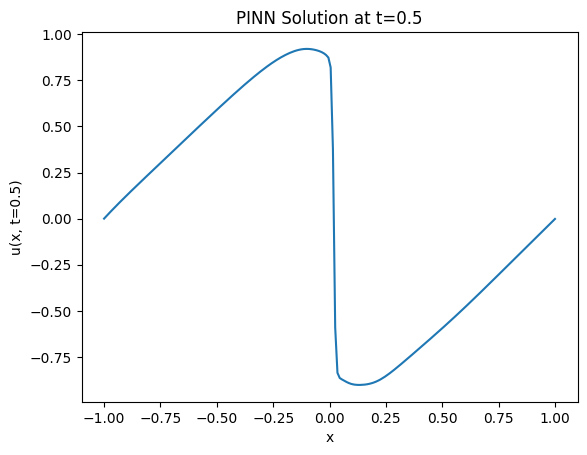

In [ ]:
x = torch.linspace(-1, 1, 200).view(-1,1).to(device)
t = torch.ones_like(x) * 0.5

u_pred = model(x, t).detach().cpu().numpy()

plt.plot(x.cpu(), u_pred)
plt.xlabel("x")
plt.ylabel("u(x, t=0.5)")
plt.title("PINN Solution at t=0.5")
plt.show()

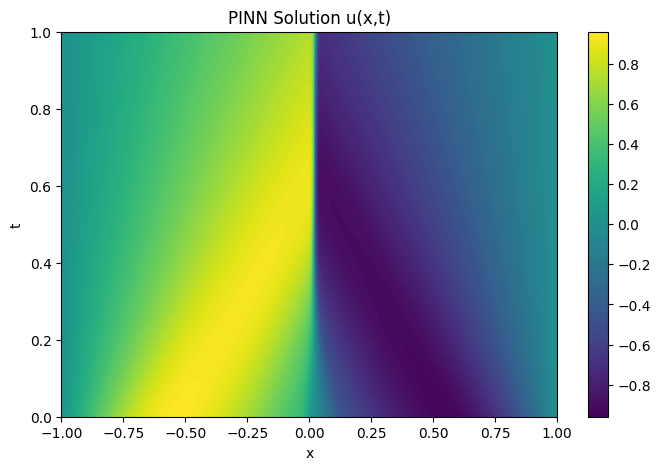

In [ ]:
x = np.linspace(-1, 1, 200)
t = np.linspace(0, 1, 100)

X, T = np.meshgrid(x, t)

X_torch = torch.tensor(X.flatten(), dtype=torch.float32).view(-1,1).to(device)
T_torch = torch.tensor(T.flatten(), dtype=torch.float32).view(-1,1).to(device)

u_pred = model(X_torch, T_torch)
U = u_pred.detach().cpu().numpy().reshape(X.shape)

# Plot contour
plt.figure(figsize=(8,5))
cp = plt.contourf(X, T, U, 100)
plt.colorbar(cp)
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Solution u(x,t)")
plt.show()